In [1]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import numpy as np
import os
from PIL import Image

In [2]:
# Load original image
image = cv2.cvtColor(cv2.imread("test/image.png"), cv2.COLOR_BGR2RGB)

In [ ]:
# Mask, Bounding box, keypoints

# Bounding box (x, y, w, h)
x, y, w, h = 250, 330, 50, 50
bboxes = [(x, y, w, h)]
bbox_labels = ["white_spot"]

# Keypoints
kp = [(450, 470), (100, 340), (475, 235), (370, 300), (260, 480)]

# first array as the shape, second as the x y axis
mask_coords = np.array([[240, 340], [300, 330], [310, 380], [250, 390]]) + np.array([200, 150])
mask = np.zeros(image.shape[:2], dtype=np.uint8)
cv2.fillPoly(mask, [mask_coords], 255)


In [4]:
# Augmentation pipeline

transformer = A.Compose(
    [   # All of the steps p value is 1 just to test and show it all works

        # Pixel Level transformation
        A.AdditiveNoise( # Pixel level noise, must be first so it work properly with spatials
            noise_type="gaussian",
            spatial_mode="per_pixel",
            noise_params={"mean_range":[0,0], "std_range":[0.02,0.1]}, # low noise, just for visualization
            approximation=1,
            p=1
        ),
        
        # Spatial transforms
        A.Affine(
            scale=[0.9, 1.1], # Zoom out by 10% or zoom in by 10%
            # Negative means it can be translated, rotated, sheered to different directions
            translate_percent=[-0.02, 0.02], 
            rotate=[-15, 15],
            shear=[-5, 5], 
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            rotate_method="ellipse",
            balanced_scale=True,
            border_mode=cv2.BORDER_CONSTANT,
            p=1
        ),
        A.GridElasticDeform( # Makes it wiggly
            num_grid_xy=[10, 10],
            magnitude=10,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            p=1
        ),
        A.Perspective( # Changes the perspective of view in 3d 
            scale=[0.1, 0.3],
            keep_size=True,
            fit_output=True,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            border_mode=cv2.BORDER_CONSTANT,
            p=1
        ),
        A.Morphological( # Ice glass effect
            # increased scale increases kernel size, which then messes with the image. I couldn't figure out the exact reason of it but scale=1 works properly
            scale=1,
            operation="dilation",
            p=1
        ),
        A.RandomGridShuffle(
            grid=[3, 3],
            p=1
        )
    ],
    bbox_params=A.BboxParams(format='coco', label_fields=['bbox_labels']),
    keypoint_params=A.KeypointParams(format='xy')
)
augmented = transformer(
    image=image,
    mask=mask,
    bboxes=bboxes,
    bbox_labels=bbox_labels,
    keypoints=kp
)

In [5]:
# Extract outputs
image_aug = augmented['image']
mask_aug = augmented['mask']
bboxes_aug = augmented['bboxes']
keypoints_aug = augmented['keypoints']

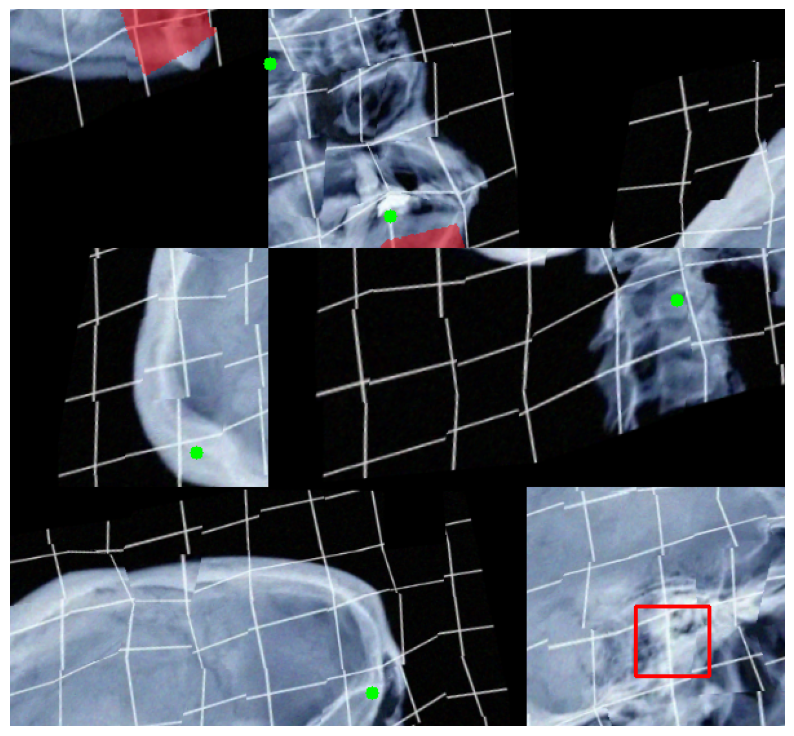

In [6]:
# Visualize 

#  augmented bounding boxes
for (bx, by, bw, bh) in bboxes_aug:
    cv2.rectangle(image_aug, (int(bx), int(by)), (int(bx+bw), int(by+bh)), (255, 0, 0), 2)
    
#   augmented keypoints
for (kx, ky) in keypoints_aug:
    cv2.circle(image_aug, (int(kx), int(ky)), 5, (0, 255, 0), -1)

# Overlay augmented mask
overlay = image_aug.copy()
red_layer = np.zeros_like(image_aug)
red_layer[..., 0] = 255  # red channel
alpha = 0.5
mask_bool = mask_aug.astype(bool)[..., np.newaxis]  # broadcast over 3 channels
overlay = np.where(mask_bool, (1-alpha)*overlay + alpha*red_layer, overlay).astype(np.uint8)

# Show final image
plt.figure(figsize=(10,10))
plt.imshow(overlay)
plt.axis('off')
plt.show()


In [5]:
base_path = "train/"
images = []
masks = []
labels = []
def read_image_any(path):
    # Try OpenCV first
    img = cv2.imread(path)
    if img is not None:
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # If it's a GIF or something OpenCV can't read, use Pillow
    try:
        with Image.open(path) as im:
            im = im.convert("RGB")  # Convert to 3-channel RGB
            return np.array(im)
    except Exception as e:
        print(f"Could not read image: {path} ({e})")
        return None

def load_image():
    for folder_name in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder_name)
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            img = read_image_any(file_path)
            if img is None:
                continue

            if folder_name == "eyes":
                images.append(img)
            elif folder_name == "labels":
                labels.append(img)
            elif folder_name == "masks":
                masks.append(img)
load_image()

Text(0.5, 1.0, 'Label (Vessels)')

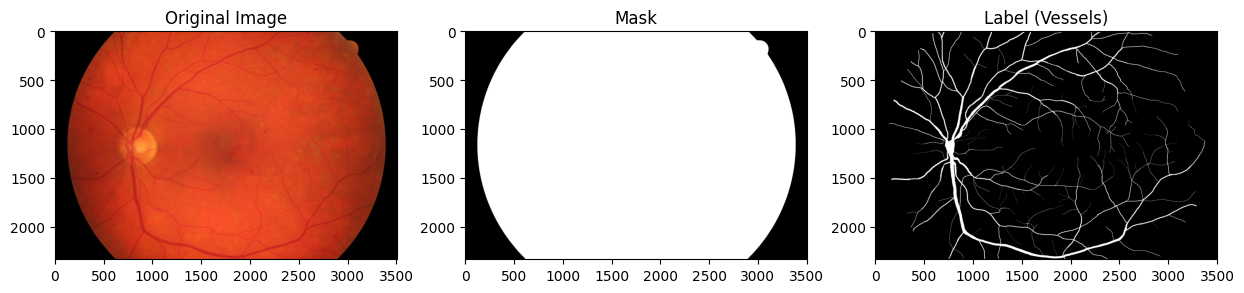

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(images[0])
axes[0].set_title("Original Image")

axes[1].imshow(masks[0])
axes[1].set_title("Mask")

axes[2].imshow(labels[0])
axes[2].set_title("Label (Vessels)")

In [12]:
# Pipeline for homework

train_transform = A.Compose([
    ### Geometric transforms
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.Affine(
            scale=[0.9, 1.1], # Zoom out by 10% or zoom in by 10%
            # Negative means it can be translated, rotated, sheered to different directions
            translate_percent=[-0.02, 0.02], 
            rotate=[-15, 15],
            shear=[-5, 5], 
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            rotate_method="ellipse",
            balanced_scale=True,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.7
        ),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.7
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=10,
        val_shift_limit=10,
        p=0.7
    ),
    A.CLAHE(
        clip_limit = 2,
        p=0.4
    ),
    A.OneOf([
        A.ElasticTransform(alpha=50, sigma=5, p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.3),
        A.OpticalDistortion(distort_limit=0.05, p=0.3),
    ])
],
                            additional_targets={"mask": "mask", "label": "mask"})

aug = train_transform(image=images[0], mask=masks[0], label=labels[0])

Text(0.5, 1.0, 'Label (Vessels)')

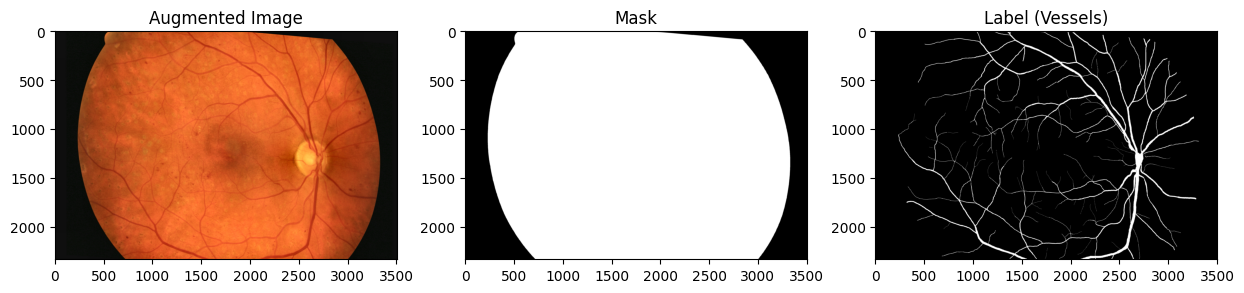

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(aug["image"])
axes[0].set_title("Augmented Image")

axes[1].imshow(aug["mask"])
axes[1].set_title("Mask")

axes[2].imshow(aug["label"])
axes[2].set_title("Label (Vessels)")